# Regression Analysis - House Price Prediction

## Dataset Path https://raw.githubusercontent.com/swapnilsaurav/MachineLearning/refs/heads/master/Examples/Regression/ml_regression_property_dataset.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### Cleaning the data before analysis

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/swapnilsaurav/MachineLearning/refs/heads/master/Examples/Regression/ml_regression_property_dataset.csv")

In [4]:
pd.set_option('display.max_columns', 33)
df.head(5)

,Property_ID,Listing_Date,City,Locality,Property_Type,BHK,Built_Up_Area_sqft,Carpet_Area_sqft,Age_Years,Floor,Total_Floors,Bathrooms,Parking_Spaces,Furnishing_Status,Facing,Gated_Community,Distance_to_Metro_km,Distance_to_CBD_km,Nearby_Schools,Crime_Index,Amenities_Score,Monthly_Maintenance_INR,Seller_Type,Loan_Available,Annual_Property_Tax_INR,Price_Lakhs
0,PROP-10001,2026-03-09,Pune,Hinjewadi,Villa,3,1633.0,1328.1,12.0,Ground,4,2,0,Unfurnished,North-East,Yes,6.31,23.12,8,26.7,8.3,4860,Broker,Yes,32800,134.64
1,PROP-10002,2025-10-12,Bengaluru,Whitefield,Apartment,2,1443.3,1070.8,9.0,6,8,1,1,NaN,North-East,No,5.78,10.55,1,50.0,7.1,4350,Builder,Yes,34800,115.27
2,PROP-10003,2026-08-04,Delhi NCR,Noida,Apartment,2,1002.7,798.8,28.0,8,11,2,1,Semi-Furnished,South-East,Yes,NaN,19.59,12,43.9,5.8,2120,Builder,Yes,25900,51.32
3,PROP-10004,2025-09-15,Bengaluru,Marathahalli,Apartment,2,1303.4,1061.1,0.0,11,26,2,3,Unfurnished,West,Yes,3.47,16.73,10,44.2,8.8,5330,Owner,Yes,45000,144.92
4,PROP-10005,2026-07-07,Delhi NCR,Gurugram,Villa,3,1898.5,1553.6,0.0,3rd,3,2,3,Furnished,East,no,5.09,5.19,1,51.3,4.5,8040,Owner,Yes,77200,216.85


In [5]:
df.describe(include = 'all')

,Property_ID,Listing_Date,City,Locality,Property_Type,BHK,Built_Up_Area_sqft,Carpet_Area_sqft,Age_Years,Floor,Total_Floors,Bathrooms,Parking_Spaces,Furnishing_Status,Facing,Gated_Community,Distance_to_Metro_km,Distance_to_CBD_km,Nearby_Schools,Crime_Index,Amenities_Score,Monthly_Maintenance_INR,Seller_Type,Loan_Available,Annual_Property_Tax_INR,Price_Lakhs
count,1000,1000,1000,1000,1000,1000.000000,975.000000,946.000000,959.000000,1000,1000.000000,1000.000000,1000.000000,966,1000,1000,939.000000,1000.000000,1000.000000,970.000000,975.000000,1000.000000,981,1000,1000.000000,1000.00000
unique,990,499,16,25,4,NaN,NaN,NaN,NaN,38,NaN,NaN,NaN,8,6,8,NaN,NaN,NaN,NaN,NaN,NaN,3,2,NaN,NaN
top,PROP-10145,2025-05-16,Hyderabad,Madhapur,Apartment,NaN,NaN,NaN,NaN,Ground,NaN,NaN,NaN,Semi-Furnished,North,Yes,NaN,NaN,NaN,NaN,NaN,NaN,Owner,Yes,NaN,NaN
freq,2,9,277,64,675,NaN,NaN,NaN,NaN,170,NaN,NaN,NaN,415,184,702,NaN,NaN,NaN,NaN,NaN,NaN,363,888,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2.781000,1587.730051,1164.936786,11.758081,NaN,12.687000,2.780000,1.286000,NaN,NaN,NaN,5.306954,13.676970,6.090000,42.255155,6.717949,6181.170000,NaN,NaN,46840.000000,122.51979
std,NaN,NaN,NaN,NaN,NaN,1.056482,1158.704011,530.953578,10.549014,NaN,10.983153,1.193744,0.773823,NaN,NaN,NaN,4.638007,6.591397,3.726095,15.833687,2.068368,6689.371735,NaN,NaN,25175.274665,55.27897
min,NaN,NaN,NaN,NaN,NaN,1.000000,320.000000,268.900000,0.000000,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,0.200000,1.000000,0.000000,5.000000,0.000000,1150.000000,NaN,NaN,10100.000000,18.00000
25%,NaN,NaN,NaN,NaN,NaN,2.000000,1008.000000,780.400000,5.000000,NaN,3.000000,2.000000,1.000000,NaN,NaN,NaN,2.840000,8.820000,3.000000,31.225000,5.200000,3440.000000,NaN,NaN,28300.000000,83.31000
50%,NaN,NaN,NaN,NaN,NaN,3.000000,1356.600000,1042.200000,10.000000,NaN,9.000000,3.000000,1.000000,NaN,NaN,NaN,5.060000,13.870000,6.000000,41.900000,6.800000,5095.000000,NaN,NaN,40500.000000,112.18000
75%,NaN,NaN,NaN,NaN,NaN,4.000000,1881.300000,1458.125000,16.000000,NaN,22.000000,4.000000,2.000000,NaN,NaN,NaN,7.075000,18.462500,9.000000,52.600000,8.300000,7212.500000,NaN,NaN,58700.000000,152.76500


In [6]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Property_ID              1000 non-null   str    
 1   Listing_Date             1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Locality                 1000 non-null   str    
 4   Property_Type            1000 non-null   str    
 5   BHK                      1000 non-null   int64  
 6   Built_Up_Area_sqft       975 non-null    float64
 7   Carpet_Area_sqft         946 non-null    float64
 8   Age_Years                959 non-null    float64
 9   Floor                    1000 non-null   str    
 10  Total_Floors             1000 non-null   int64  
 11  Bathrooms                1000 non-null   int64  
 12  Parking_Spaces           1000 non-null   int64  
 13  Furnishing_Status        966 non-null    str    
 14  Facing                   1000 non-nu

(1000, 26)

In [7]:
missing_df = pd.DataFrame({'Columns':df.columns,
                           'Missing Values':df.isnull().sum().values,
                           'Missing Percentage':df.isnull().sum().values/len(df) *100})
missing_df

,Columns,Missing Values,Missing Percentage
0,Property_ID,0,0.0
1,Listing_Date,0,0.0
2,City,0,0.0
3,Locality,0,0.0
4,Property_Type,0,0.0
5,BHK,0,0.0
6,Built_Up_Area_sqft,25,2.5
7,Carpet_Area_sqft,54,5.4
8,Age_Years,41,4.1
9,Floor,0,0.0


In [8]:
df.describe()

,BHK,Built_Up_Area_sqft,Carpet_Area_sqft,Age_Years,Total_Floors,Bathrooms,Parking_Spaces,Distance_to_Metro_km,Distance_to_CBD_km,Nearby_Schools,Crime_Index,Amenities_Score,Monthly_Maintenance_INR,Annual_Property_Tax_INR,Price_Lakhs
count,1000.000000,975.000000,946.000000,959.000000,1000.000000,1000.000000,1000.000000,939.000000,1000.000000,1000.000000,970.000000,975.000000,1000.000000,1000.000000,1000.00000
mean,2.781000,1587.730051,1164.936786,11.758081,12.687000,2.780000,1.286000,5.306954,13.676970,6.090000,42.255155,6.717949,6181.170000,46840.000000,122.51979
std,1.056482,1158.704011,530.953578,10.549014,10.983153,1.193744,0.773823,4.638007,6.591397,3.726095,15.833687,2.068368,6689.371735,25175.274665,55.27897
min,1.000000,320.000000,268.900000,0.000000,1.000000,1.000000,0.000000,0.200000,1.000000,0.000000,5.000000,0.000000,1150.000000,10100.000000,18.00000
25%,2.000000,1008.000000,780.400000,5.000000,3.000000,2.000000,1.000000,2.840000,8.820000,3.000000,31.225000,5.200000,3440.000000,28300.000000,83.31000
50%,3.000000,1356.600000,1042.200000,10.000000,9.000000,3.000000,1.000000,5.060000,13.870000,6.000000,41.900000,6.800000,5095.000000,40500.000000,112.18000
75%,4.000000,1881.300000,1458.125000,16.000000,22.000000,4.000000,2.000000,7.075000,18.462500,9.000000,52.600000,8.300000,7212.500000,58700.000000,152.76500
max,5.000000,14533.900000,3322.700000,91.000000,35.000000,6.000000,3.000000,66.930000,34.880000,12.000000,90.400000,10.000000,111920.000000,163000.000000,374.37000


In [9]:
num_col =  ['Built_Up_Area_sqft','Carpet_Area_sqft','Age_Years','Distance_to_Metro_km','Crime_Index','Amenities_Score']
df[num_col] = df[num_col].fillna(df[num_col].median())

In [10]:
cat_col = ['Furnishing_Status','Seller_Type']
for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Property_ID              1000 non-null   str    
 1   Listing_Date             1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Locality                 1000 non-null   str    
 4   Property_Type            1000 non-null   str    
 5   BHK                      1000 non-null   int64  
 6   Built_Up_Area_sqft       1000 non-null   float64
 7   Carpet_Area_sqft         1000 non-null   float64
 8   Age_Years                1000 non-null   float64
 9   Floor                    1000 non-null   str    
 10  Total_Floors             1000 non-null   int64  
 11  Bathrooms                1000 non-null   int64  
 12  Parking_Spaces           1000 non-null   int64  
 13  Furnishing_Status        1000 non-null   str    
 14  Facing                   1000 non-nu

In [12]:
df.duplicated().sum()

np.int64(10)

In [13]:
df[df.duplicated()]

,Property_ID,Listing_Date,City,Locality,Property_Type,BHK,Built_Up_Area_sqft,Carpet_Area_sqft,Age_Years,Floor,Total_Floors,Bathrooms,Parking_Spaces,Furnishing_Status,Facing,Gated_Community,Distance_to_Metro_km,Distance_to_CBD_km,Nearby_Schools,Crime_Index,Amenities_Score,Monthly_Maintenance_INR,Seller_Type,Loan_Available,Annual_Property_Tax_INR,Price_Lakhs
902,PROP-10411,2026-03-03,Delhi NCR,Dwarka,Apartment,3,1270.2,896.1,17.0,12,14,4,3,Semi-Furnished,North-East,Yes,5.06,17.30,11,41.9,3.4,3140,Owner,Yes,25900,85.37
911,PROP-10647,2025-05-20,Pune,Wakad,Apartment,4,2606.2,2009.5,43.0,2,10,4,1,Unfurnished,North-East,Yes,4.68,10.98,6,46.7,10.0,8330,Builder,Yes,53000,144.57
914,PROP-10656,2025-10-12,Bengaluru,Electronic City,Independent House,3,1439.7,1121.7,20.0,Ground,3,3,2,Furnished,North,Yes,2.62,1.00,9,67.1,7.6,6510,Builder,No,35400,153.11
920,PROP-10843,2025-08-14,Pune,Baner,Apartment,2,1312.0,907.9,5.0,16,18,2,1,Semi-Furnished,South-East,Yes,0.25,5.87,8,59.3,5.0,6320,Builder,Yes,26300,105.43
927,PROP-10410,2025-10-29,Delhi NCR,Gurugram,Independent House,2,830.4,576.2,10.0,Ground,1,2,1,Furnished,North,No,5.19,3.68,8,42.7,2.4,3250,Owner,Yes,26500,84.04
937,PROP-10550,2026-03-17,Delhi NCR,Noida,Apartment,2,1119.2,891.7,10.0,1st,2,2,1,Furnished,South-East,Yes,2.02,14.22,8,41.9,9.1,5100,Broker,Yes,29700,103.88
943,PROP-10818,2025-04-05,Delhi NCR,Noida,Apartment,2,1148.2,822.1,19.0,Ground,17,3,2,Furnished,West,Yes,2.95,1.00,8,40.5,2.0,4690,Builder,Yes,26800,99.96
944,PROP-10145,2025-12-06,Hyderabad,Kondapur,Apartment,2,1465.5,1200.6,21.0,1,5,2,2,Semi furnished,North,Yes,8.02,1.00,11,45.6,4.4,7750,Broker,Yes,42500,94.75
949,PROP-10701,2025-07-20,Hyderabad,Kondapur,Independent House,4,2197.1,1714.5,3.0,1,1,4,1,Semi-Furnished,West,Yes,3.78,8.51,10,12.2,10.0,11380,Broker,Yes,68000,196.38
969,PROP-10388,2025-10-01,Hyderabad,Kukatpally,Apartment,1,690.0,512.7,6.0,15,26,1,2,Unfurnished,North-East,Yes,2.76,9.94,3,13.8,5.6,2270,Owner,Yes,16500,72.35


In [14]:
df = df.drop_duplicates().reset_index(drop= True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['Listing_Date'] = pd.to_datetime(df['Listing_Date'])

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Property_ID              990 non-null    str           
 1   Listing_Date             990 non-null    datetime64[us]
 2   City                     990 non-null    str           
 3   Locality                 990 non-null    str           
 4   Property_Type            990 non-null    str           
 5   BHK                      990 non-null    int64         
 6   Built_Up_Area_sqft       990 non-null    float64       
 7   Carpet_Area_sqft         990 non-null    float64       
 8   Age_Years                990 non-null    float64       
 9   Floor                    990 non-null    str           
 10  Total_Floors             990 non-null    int64         
 11  Bathrooms                990 non-null    int64         
 12  Parking_Spaces           990 non-null    int64 

### Examine Unique Categorical Values

In [18]:
categorical_columns = df.select_dtypes(include = 'str').columns
categorical_columns

Index(['Property_ID', 'City', 'Locality', 'Property_Type', 'Floor',
       'Furnishing_Status', 'Facing', 'Gated_Community', 'Seller_Type',
       'Loan_Available'],
      dtype='str')

In [19]:
for column in categorical_columns:
    if column not in ['Property_ID']:
        print(df[column].unique())

<StringArray>
[      'Pune',  'Bengaluru',  'Delhi NCR',  'Hyderabad',    'Chennai',
 ' Hyderabad',    'CHENNAI',  'HYDERABAD',  'hyderabad',       'PUNE',
  'DELHI NCR',       'pune',      ' Pune', ' Bengaluru', ' Delhi NCR',
   ' Chennai']
Length: 16, dtype: str
<StringArray>
[      'Hinjewadi',      'Whitefield',           'Noida',    'Marathahalli',
        'Gurugram',           'Baner',      'HSR Layout',      'Kukatpally',
 'Electronic City',        'Madhapur',       'Ghaziabad',       'Velachery',
       'Yelahanka',      'Anna Nagar',      'Gachibowli',             'OMR',
        'Kondapur',           'Wakad',           'Porur',         'Kharadi',
          'Dwarka',       'Manikonda',        'Tambaram',        'Hadapsar',
       'Faridabad']
Length: 25, dtype: str
<StringArray>
['Villa', 'Apartment', 'Independent House', 'Studio']
Length: 4, dtype: str
<StringArray>
['Ground',      '6',      '8',     '11',    '3rd',      '7',      '3',
     '14',      '9',      '5',    '2nd', 

### Cleaning the Columns

#### Cleaning the column city

In [20]:
df['City'] = df['City'].astype(str).str.strip().str.title()

In [21]:
df['City'] = df['City'].replace('Delhi Ncr','Delhi NCR')

In [22]:
df['City'].unique()

<StringArray>
['Pune', 'Bengaluru', 'Delhi NCR', 'Hyderabad', 'Chennai']
Length: 5, dtype: str

#### Cleaning the column floor

In [23]:
def cleanfloor(value):
    if pd.isna(value):
        return np.nan
    if value == 'Ground':
        return 0
    value = str(value).strip().lower()
    value = (value.replace('st','').replace('nd','').replace('rd','').replace('th',''))
    try:
        return int(value)
    except:
        return np.nan

In [24]:
df['Floor_num'] = df['Floor'].apply(cleanfloor)
df['Floor_num'].unique()

array([ 0,  6,  8, 11,  3,  7, 14,  9,  5,  2, 19, 21,  1, 17, 29, 26,  4,
       27, 20, 15, 18, 12, 31, 13, 10, 16, 24, 30, 23, 28, 25, 22, 32, 33,
       34])

In [25]:
df['Furnishing_Status'] = df['Furnishing_Status'].str.strip().str.title()

In [26]:
df['Furnishing_Status'] = df['Furnishing_Status'].replace('Semi-Furnished','Semi Furnished')
df['Furnishing_Status'].unique()

<StringArray>
['Unfurnished', 'Semi Furnished', 'Furnished']
Length: 3, dtype: str

In [27]:
df['Furnishing_Status'].value_counts()

Furnishing_Status
Semi Furnished    458
Unfurnished       356
Furnished         176
Name: count, dtype: int64

In [28]:
df['Gated_Community'] = df['Gated_Community'].str.strip().str.title().replace('Y','Yes').replace('N','No')

In [29]:
df['Gated_Community'].value_counts()

Gated_Community
Yes    705
No     285
Name: count, dtype: int64

## Feature Engineering

In [30]:
df['Listing_Year'] = df['Listing_Date'].dt.year
df['Listing_Month'] = df['Listing_Date'].dt.month
df['Listing_Quarter'] = df['Listing_Date'].dt.quarter


In [31]:
reference_date = df['Listing_Date'].max()
df['Days_Since_Listings'] = (reference_date - df['Listing_Date']).dt.days
df.head(5)

,Property_ID,Listing_Date,City,Locality,Property_Type,BHK,Built_Up_Area_sqft,Carpet_Area_sqft,Age_Years,Floor,Total_Floors,Bathrooms,Parking_Spaces,Furnishing_Status,Facing,Gated_Community,Distance_to_Metro_km,Distance_to_CBD_km,Nearby_Schools,Crime_Index,Amenities_Score,Monthly_Maintenance_INR,Seller_Type,Loan_Available,Annual_Property_Tax_INR,Price_Lakhs,Floor_num,Listing_Year,Listing_Month,Listing_Quarter,Days_Since_Listings
0,PROP-10001,2026-03-09,Pune,Hinjewadi,Villa,3,1633.0,1328.1,12.0,Ground,4,2,0,Unfurnished,North-East,Yes,6.31,23.12,8,26.7,8.3,4860,Broker,Yes,32800,134.64,0,2026,3,1,178
1,PROP-10002,2025-10-12,Bengaluru,Whitefield,Apartment,2,1443.3,1070.8,9.0,6,8,1,1,Semi Furnished,North-East,No,5.78,10.55,1,50.0,7.1,4350,Builder,Yes,34800,115.27,6,2025,10,4,326
2,PROP-10003,2026-08-04,Delhi NCR,Noida,Apartment,2,1002.7,798.8,28.0,8,11,2,1,Semi Furnished,South-East,Yes,5.06,19.59,12,43.9,5.8,2120,Builder,Yes,25900,51.32,8,2026,8,3,30
3,PROP-10004,2025-09-15,Bengaluru,Marathahalli,Apartment,2,1303.4,1061.1,0.0,11,26,2,3,Unfurnished,West,Yes,3.47,16.73,10,44.2,8.8,5330,Owner,Yes,45000,144.92,11,2025,9,3,353
4,PROP-10005,2026-07-07,Delhi NCR,Gurugram,Villa,3,1898.5,1553.6,0.0,3rd,3,2,3,Furnished,East,No,5.09,5.19,1,51.3,4.5,8040,Owner,Yes,77200,216.85,3,2026,7,3,58


### Drop Columns Which Are Not Required

In [32]:
df = df.drop(columns = ['Listing_Date','Property_ID','Floor'])
df.head()

,City,Locality,Property_Type,BHK,Built_Up_Area_sqft,Carpet_Area_sqft,Age_Years,Total_Floors,Bathrooms,Parking_Spaces,Furnishing_Status,Facing,Gated_Community,Distance_to_Metro_km,Distance_to_CBD_km,Nearby_Schools,Crime_Index,Amenities_Score,Monthly_Maintenance_INR,Seller_Type,Loan_Available,Annual_Property_Tax_INR,Price_Lakhs,Floor_num,Listing_Year,Listing_Month,Listing_Quarter,Days_Since_Listings
0,Pune,Hinjewadi,Villa,3,1633.0,1328.1,12.0,4,2,0,Unfurnished,North-East,Yes,6.31,23.12,8,26.7,8.3,4860,Broker,Yes,32800,134.64,0,2026,3,1,178
1,Bengaluru,Whitefield,Apartment,2,1443.3,1070.8,9.0,8,1,1,Semi Furnished,North-East,No,5.78,10.55,1,50.0,7.1,4350,Builder,Yes,34800,115.27,6,2025,10,4,326
2,Delhi NCR,Noida,Apartment,2,1002.7,798.8,28.0,11,2,1,Semi Furnished,South-East,Yes,5.06,19.59,12,43.9,5.8,2120,Builder,Yes,25900,51.32,8,2026,8,3,30
3,Bengaluru,Marathahalli,Apartment,2,1303.4,1061.1,0.0,26,2,3,Unfurnished,West,Yes,3.47,16.73,10,44.2,8.8,5330,Owner,Yes,45000,144.92,11,2025,9,3,353
4,Delhi NCR,Gurugram,Villa,3,1898.5,1553.6,0.0,3,2,3,Furnished,East,No,5.09,5.19,1,51.3,4.5,8040,Owner,Yes,77200,216.85,3,2026,7,3,58


## Exploratory Data Analysis

### 1. Monthly Maintainance Cost

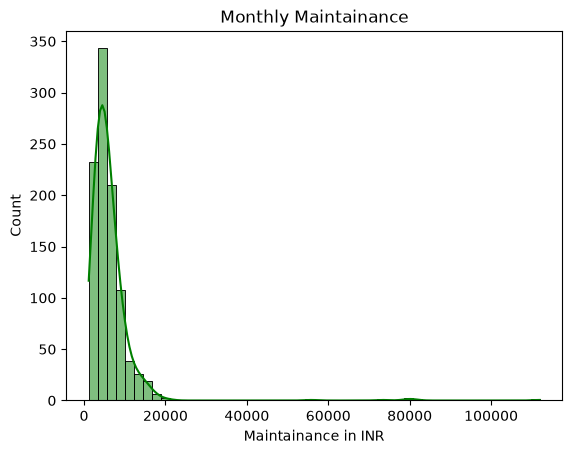

In [33]:
sns.histplot( data = df, x = 'Monthly_Maintenance_INR' , bins = 50 ,kde = True,color = 'green')
plt.title("Monthly Maintainance")
plt.xlabel("Maintainance in INR")
plt.ylabel("Count")
plt.show()

### 2. Types of Property Listed

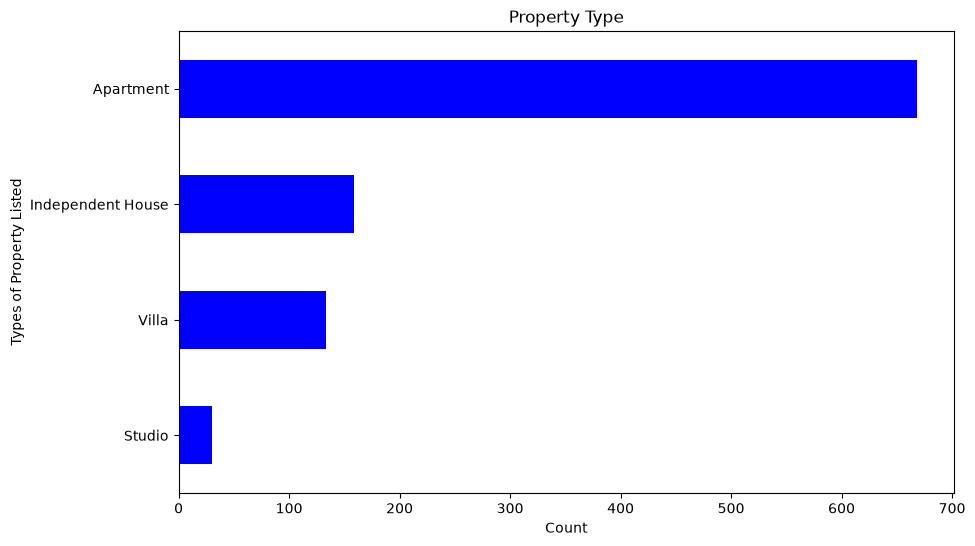

In [34]:
types = df['Property_Type'].value_counts()
types.plot(kind='barh', figsize=(10,6), color = 'blue')
plt.title("Property Type")
plt.xlabel("Count")
plt.ylabel("Types of Property Listed")
plt.gca().invert_yaxis()
plt.show()

### 3. Distribution Of Property Prices

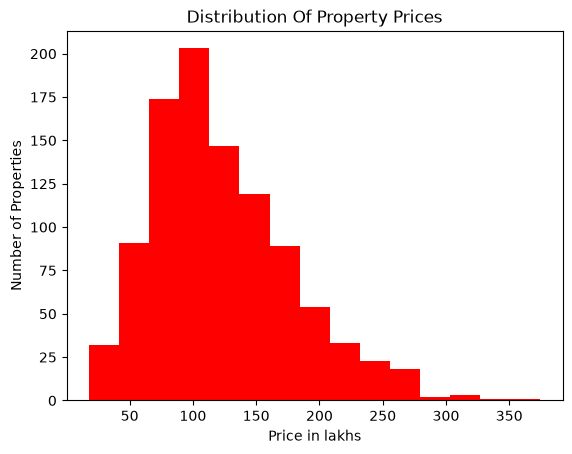

In [35]:
plt.hist(df['Price_Lakhs'],bins = 15,color = 'red')
plt.title("Distribution Of Property Prices")
plt.xlabel("Price in lakhs")
plt.ylabel("Number of Properties")
plt.show()

### 4. Propery Density by Distance to Metro and CBD

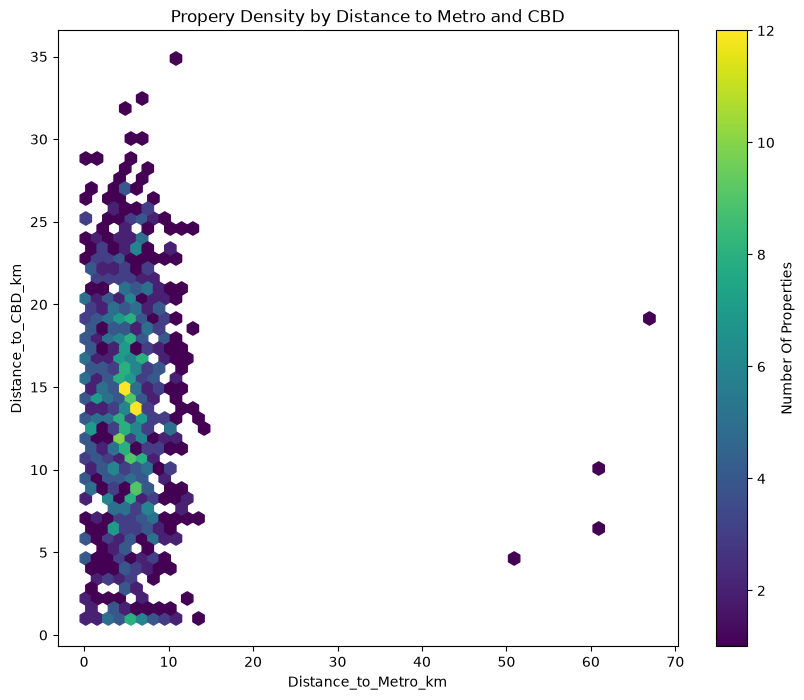

In [36]:
plt.figure(figsize=(10, 8))
plt.hexbin(df['Distance_to_Metro_km'],df['Distance_to_CBD_km'],gridsize=50,mincnt=1,cmap='viridis')
plt.colorbar(label='Number Of Properties')
plt.xlabel('Distance_to_Metro_km')
plt.ylabel('Distance_to_CBD_km')
plt.title('Propery Density by Distance to Metro and CBD')
plt.show()

### 5. Price By Location

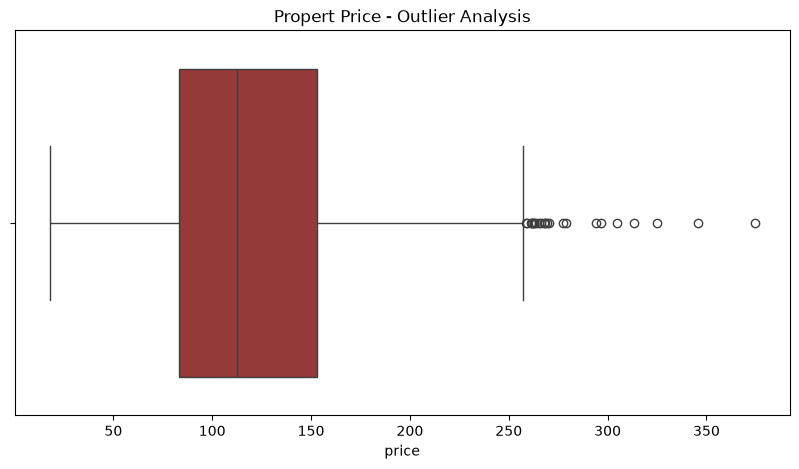

In [37]:
plt.figure(figsize = (10,5))
sns.boxplot(x = df['Price_Lakhs'],color = 'brown')
plt.title('Propert Price - Outlier Analysis')
plt.xlabel('price')
plt.show()

### 6. Built_Up_Area_sqft - Outlier Analysis

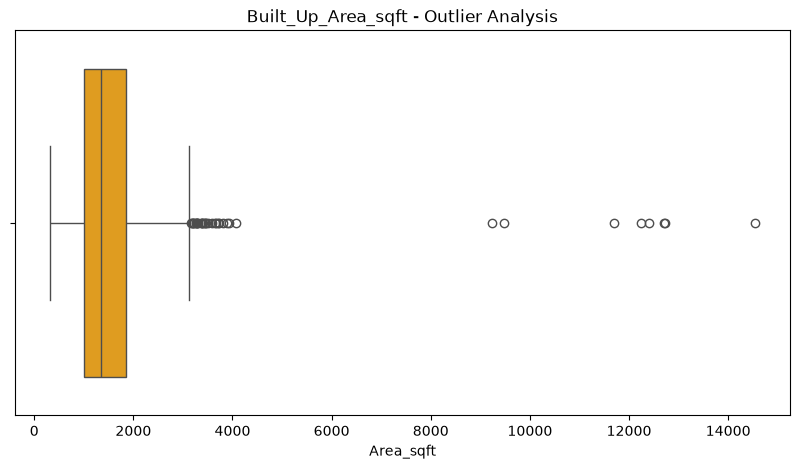

In [38]:
plt.figure(figsize = (10,5))
sns.boxplot(x = df['Built_Up_Area_sqft'],color = 'orange')
plt.title('Built_Up_Area_sqft - Outlier Analysis')
plt.xlabel('Area_sqft')
plt.show()

### 7. Price in Lakhs

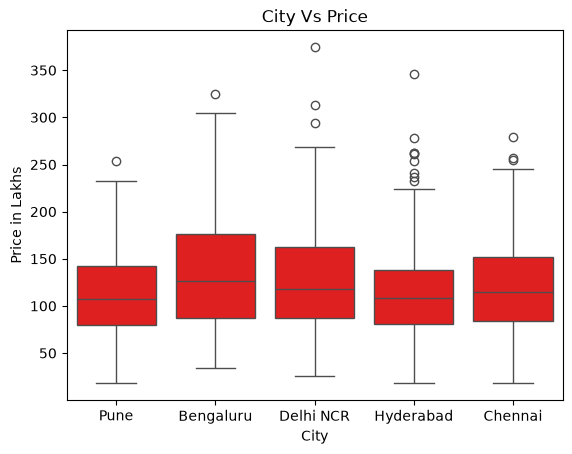

In [39]:
sns.boxplot(data=df, x='City', y='Price_Lakhs',color = 'red')
plt.title('City Vs Price')
plt.xlabel('City')
plt.ylabel('Price in Lakhs')
plt.show()

### 8. Property Age Vs Price

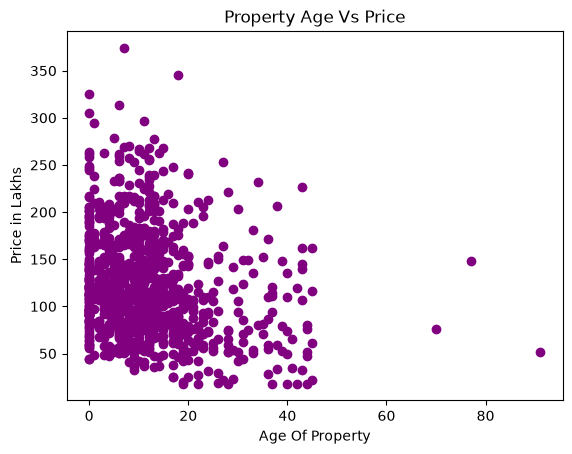

In [40]:
plt.scatter(df['Age_Years'],df['Price_Lakhs'],color = 'purple')
plt.title('Property Age Vs Price')
plt.xlabel('Age Of Property')
plt.ylabel('Price in Lakhs')
plt.show()

### 9. Property Area in Sqft Vs Price

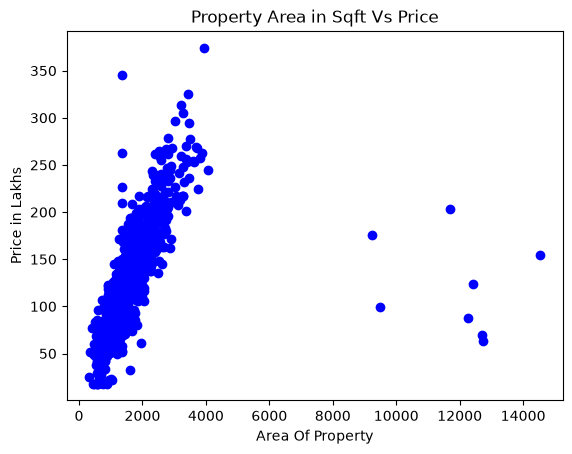

In [41]:
plt.scatter(df['Built_Up_Area_sqft'],df['Price_Lakhs'],color = 'blue')
plt.title('Property Area in Sqft Vs Price')
plt.xlabel('Area Of Property')
plt.ylabel('Price in Lakhs')
plt.show()

### 10. Correlation Heatmap Of Numerical Columns

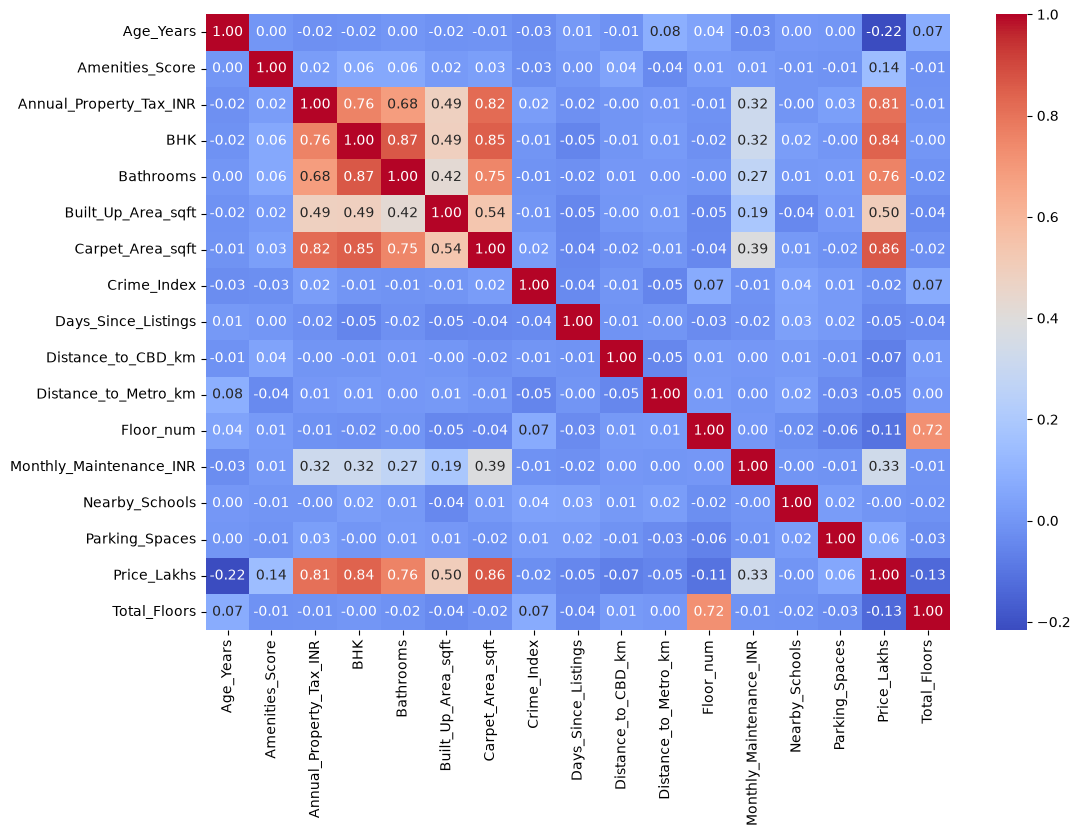

In [42]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.difference(['id'])
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### VIF Analysis - Variance Inflation Factor

In [43]:
vif_columns = df.select_dtypes(include='number').drop(columns=['Price_Lakhs'])
vif_result = pd.DataFrame()
vif_result['Feature'] = vif_columns.columns
vif_result['VIF'] =[ variance_inflation_factor(vif_columns.values,i)
                    for i in range(vif_columns.shape[1])]
vif_result  

,Feature,VIF
0,BHK,6.569217
1,Built_Up_Area_sqft,1.437922
2,Carpet_Area_sqft,5.410318
3,Age_Years,1.024754
4,Total_Floors,2.134993
5,Bathrooms,4.093924
6,Parking_Spaces,1.014909
7,Distance_to_Metro_km,1.019598
8,Distance_to_CBD_km,1.013590
9,Nearby_Schools,1.010831


Listing_Year, Listing_Month, Listing_Quarter, and Days_Since_Listings are all just different re-expressions of the same
single Listing_Date column, so they're almost perfectly collinear with each other.
Keep one and drop the rest before modeling pass

In [44]:
df1 = df.drop(columns = ['Listing_Year','Listing_Month','Listing_Quarter'])

In [45]:
df1[['BHK', 'Bathrooms', 'Carpet_Area_sqft', 'Built_Up_Area_sqft', 'Price_Lakhs']].corr()['Price_Lakhs'].sort_values(ascending=False)

Price_Lakhs           1.000000
Carpet_Area_sqft      0.864630
BHK                   0.839169
Bathrooms             0.761335
Built_Up_Area_sqft    0.497063
Name: Price_Lakhs, dtype: float64

## Machine Learning Model Building

### 1.Feature And Target Selection

In [46]:
X = df1.drop('Price_Lakhs',axis = 1)
y = df1['Price_Lakhs']

In [47]:
X.head()

,City,Locality,Property_Type,BHK,Built_Up_Area_sqft,Carpet_Area_sqft,Age_Years,Total_Floors,Bathrooms,Parking_Spaces,Furnishing_Status,Facing,Gated_Community,Distance_to_Metro_km,Distance_to_CBD_km,Nearby_Schools,Crime_Index,Amenities_Score,Monthly_Maintenance_INR,Seller_Type,Loan_Available,Annual_Property_Tax_INR,Floor_num,Days_Since_Listings
0,Pune,Hinjewadi,Villa,3,1633.0,1328.1,12.0,4,2,0,Unfurnished,North-East,Yes,6.31,23.12,8,26.7,8.3,4860,Broker,Yes,32800,0,178
1,Bengaluru,Whitefield,Apartment,2,1443.3,1070.8,9.0,8,1,1,Semi Furnished,North-East,No,5.78,10.55,1,50.0,7.1,4350,Builder,Yes,34800,6,326
2,Delhi NCR,Noida,Apartment,2,1002.7,798.8,28.0,11,2,1,Semi Furnished,South-East,Yes,5.06,19.59,12,43.9,5.8,2120,Builder,Yes,25900,8,30
3,Bengaluru,Marathahalli,Apartment,2,1303.4,1061.1,0.0,26,2,3,Unfurnished,West,Yes,3.47,16.73,10,44.2,8.8,5330,Owner,Yes,45000,11,353
4,Delhi NCR,Gurugram,Villa,3,1898.5,1553.6,0.0,3,2,3,Furnished,East,No,5.09,5.19,1,51.3,4.5,8040,Owner,Yes,77200,3,58


In [48]:
y.head()

0    134.64
1    115.27
2     51.32
3    144.92
4    216.85
Name: Price_Lakhs, dtype: float64

In [49]:
print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (990, 24)
y shape: (990,)


### 2.Train-Test Split

In [50]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)

In [51]:
print("X_train",X_train.shape)
print("X_test",X_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

X_train (792, 24)
X_test (198, 24)
y_train (792,)
y_test (198,)


### 3.Categorical Feature Check

In [52]:
X.select_dtypes(include= str).columns

Index(['City', 'Locality', 'Property_Type', 'Furnishing_Status', 'Facing',
       'Gated_Community', 'Seller_Type', 'Loan_Available'],
      dtype='str')

### Categorical Transformer - Encoding

In [53]:
cat_feature = X_train.select_dtypes(include = str).columns.tolist()
#(steps = "imputer",SimpleImputer(strategy = "mostfrequent") --> if null values not handled before

cat_transform = Pipeline(steps = [("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown = "ignore"))])

### 4.Numerical Feature Check

In [54]:
X.select_dtypes(include= np.number).columns

Index(['BHK', 'Built_Up_Area_sqft', 'Carpet_Area_sqft', 'Age_Years',
       'Total_Floors', 'Bathrooms', 'Parking_Spaces', 'Distance_to_Metro_km',
       'Distance_to_CBD_km', 'Nearby_Schools', 'Crime_Index',
       'Amenities_Score', 'Monthly_Maintenance_INR', 'Annual_Property_Tax_INR',
       'Floor_num', 'Days_Since_Listings'],
      dtype='str')

### Numerical Tranformer - StandardScalar

In [55]:
num_feature = X_train.select_dtypes(include = np.number).columns.tolist()
num_transform = Pipeline(steps = [("imputer",SimpleImputer(strategy="median")),
                                  ("scaler",StandardScaler())])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_feature])
X_test_scaled = scaler.transform(X_test[num_feature])

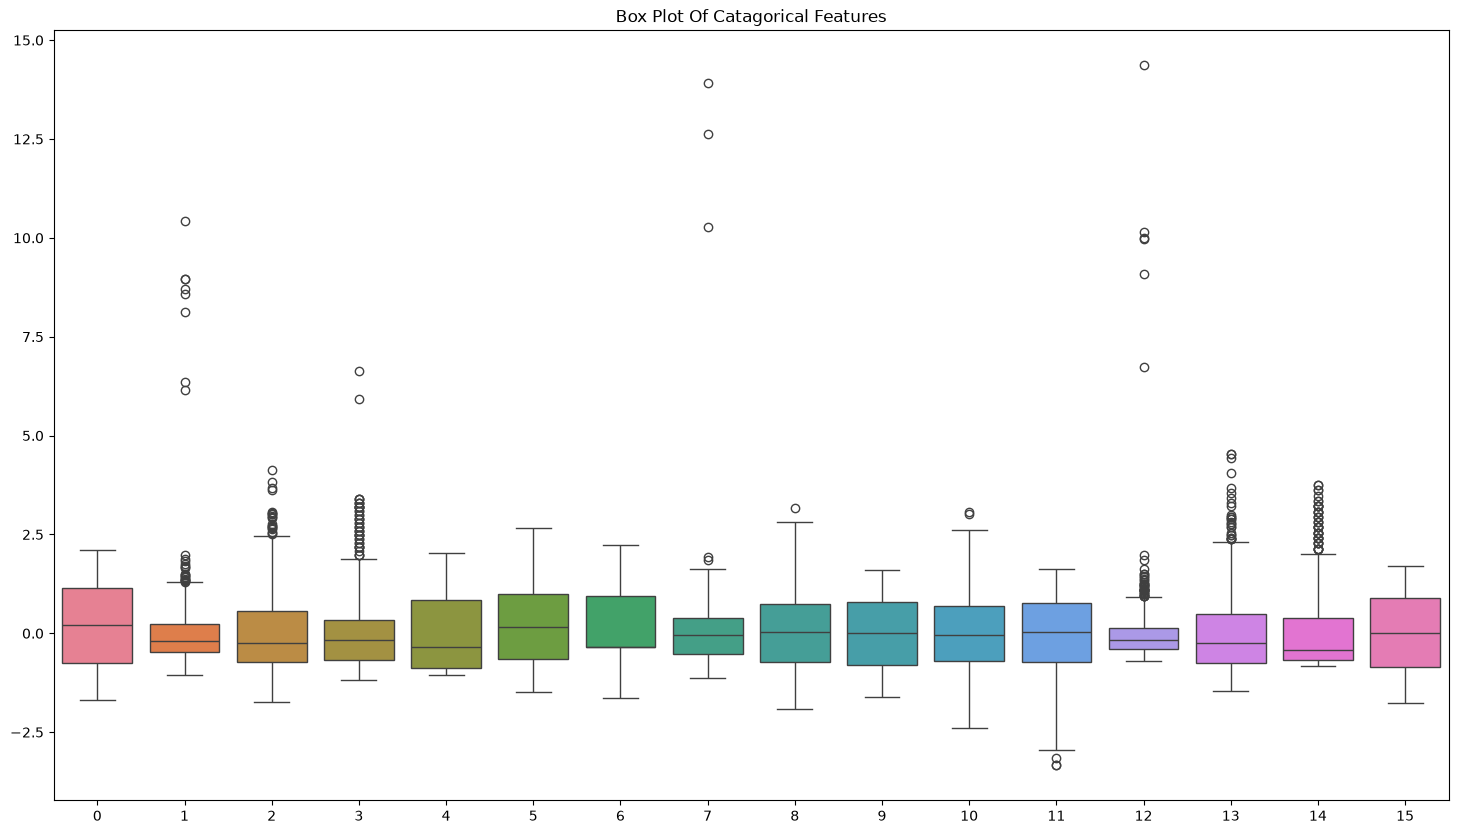

In [56]:
plt.figure(figsize = (18,10))
sns.boxplot(data= X_train_scaled)
plt.title("Box Plot Of Catagorical Features")
plt.show()

## Column Transform

In [57]:
from sklearn.compose import ColumnTransformer

In [58]:
preprocessor = ColumnTransformer(transformers = [
    ('num',num_transform,num_feature),
    ('cat',cat_transform,cat_feature)])

## Base Model

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [60]:
## We don't use X train for this baseline model

In [61]:
baseline_pred = np.repeat(y_train.mean(),len(y_test))  # Mean of y trainis repeated to the len of y test 
baseline_mae = mean_absolute_error(y_test,baseline_pred)
baseline_mse = mean_squared_error(y_test,baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test,baseline_pred)
print("Baseline mae:",baseline_mae)
print("Baseline mse:",baseline_mse)
print("Baseline rmse:",baseline_rmse)
print("Baseline r2:",baseline_r2)

Baseline mae: 43.329534231200896
Baseline mse: 3043.3117918324665
Baseline rmse: 55.16621966233019
Baseline r2: -0.002910747885427334


## 1. 1st Model - Linear Regression Model

In [62]:
data = df1[['Built_Up_Area_sqft','Price_Lakhs']]
# train-test split
X_train,X_test,y_train,y_test = train_test_split(data[['Built_Up_Area_sqft']],data['Price_Lakhs'],test_size = 0.20,random_state = 10)
#SLR Model
slr_model = LinearRegression()
slr_model.fit(X_train,y_train)
# equation y = mX + c
m = slr_model.coef_[0]
c = slr_model.intercept_
print(f"SLR Equation : y = {m}X + {c}")
# Prediction
y_pred = slr_model.predict(X_test)
# Evaluation
model_mae = mean_absolute_error(y_test,y_pred)
model_mse = mean_squared_error(y_test,y_pred)
model_rmse = np.sqrt(model_mse)
model_r2 = r2_score(y_test,y_pred)
print("SLR Model mae:",model_mae)
print("SLR Model mse:",model_mse)
print("SLR Model rmse:",model_rmse)
print("SLR Model r2:",model_r2)

SLR Equation : y = 0.02055739314713609X + 90.06335022279326
SLR Model mae: 34.06610855234823
SLR Model mse: 1927.450258653257
SLR Model rmse: 43.902736345850435
SLR Model r2: 0.364816780979925


## 2nd Model - Multiple Regression Model

In [63]:
# train test split
X = df1.drop(columns = 'Price_Lakhs')
y = df1['Price_Lakhs']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)

mlr_model = Pipeline([('preprocessor',preprocessor),('regressor',LinearRegression())])
mlr_model.fit(X_train,y_train)

# Prediction
y_pred = mlr_model.predict(X_test)
# Evaluation
model_mae = mean_absolute_error(y_test,y_pred)
model_mse = mean_squared_error(y_test,y_pred)
model_rmse = np.sqrt(model_mse)
model_r2 = r2_score(y_test,y_pred)
print("MLR Model mae:",model_mae)
print("MLR Model mse:",model_mse)
print("MLR Model rmse:",model_rmse)
print("MLR Model r2:",model_r2)


MLR Model mae: 12.633041112911974
MLR Model mse: 248.8579018615548
MLR Model rmse: 15.77523064368806
MLR Model r2: 0.9179899131127509


## Dimension Reduction - Reducing number of features while trying to retain important information

### Select K Best - Feature Selection Technique

In [64]:
from sklearn.feature_selection import SelectKBest, f_regression

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)

mlr_kbest = Pipeline(steps = [("preprocssor",preprocessor),
                              ("featureselection",SelectKBest(score_func = f_regression, k = 10)),     # 10 feactures selected
                              ("regressor",LinearRegression())
                               ])                  
mlr_kbest.fit(X_train,y_train)
y_kbest_pred = mlr_kbest.predict(X_test)
# Evaluation
kbest_mae = mean_absolute_error(y_test,y_kbest_pred)
kbest_mse = mean_squared_error(y_test,y_kbest_pred)
kbest_rmse = np.sqrt(kbest_mse)
kbest_r2 = r2_score(y_test,y_kbest_pred)
print("MLR kbest mae:",kbest_mae)
print("MLR kbest mse:",kbest_mse)
print("MLR kbest rmse:",kbest_rmse)
print("MLR kbest r2:",kbest_r2)
             

MLR kbest mae: 14.712248594954588
MLR kbest mse: 351.3105825843081
MLR kbest rmse: 18.74328099838201
MLR kbest r2: 0.8842270581459076


### Principal Compound Analysis (PCA) - Combines the features and create new features

In [66]:
from sklearn.decomposition import PCA

In [67]:
pca = Pipeline(steps = [("prepocessor",preprocessor),
                        ("pca",PCA(n_components=5)),
                        ("regressor",LinearRegression())])
pca.fit(X_train,y_train)
y_pred = pca.predict(X_test)

pca_mae = mean_absolute_error(y_test,y_pred)
pca_mse = mean_squared_error(y_test,y_pred)
pca_rmse = np.sqrt(pca_mse)
pca_r2 = r2_score(y_test,y_pred)
print("PCA mae:",pca_mae)
print("PCA mse:",pca_mse)
print("PCA rmse:",pca_rmse)
print("PCA r2:",pca_r2)

PCA mae: 15.919328231182975
PCA mse: 436.61951885954977
PCA rmse: 20.895442538016507
PCA r2: 0.8561138528835588


## 3rd Model - Ridge Regression

In [68]:
from sklearn.linear_model import Ridge

In [69]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)

ridge_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("regressor",Ridge(alpha=1.0))])
ridge_model.fit(X_train,y_train)
y_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test,y_pred)
ridge_mse = mean_squared_error(y_test,y_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test,y_pred)
print("Ridge mae:",ridge_mae)
print("Ridge mse:",ridge_mse)
print("Ridge rmse:",ridge_rmse)
print("Ridge r2:",ridge_r2)

Ridge mae: 12.583667062583665
Ridge mse: 247.58974303493932
Ridge rmse: 15.734984684928655
Ridge r2: 0.9184078295814649


In [70]:
### Ridge PCA model

In [71]:
ridge_pca_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("pca",PCA(n_components=5)),
                                ("regressor",Ridge(alpha=1.0))])
ridge_pca_model.fit(X_train,y_train)
y_pred = ridge_pca_model.predict(X_test)

ridge_pca_mae = mean_absolute_error(y_test,y_pred)
ridge_pca_mse = mean_squared_error(y_test,y_pred)
ridge_pca_rmse = np.sqrt(ridge_pca_mse)
ridge_pca_r2 = r2_score(y_test,y_pred)
print("PCA Ridge mae:",ridge_pca_mae)
print("PCA Ridge mse:",ridge_pca_mse)
print("PCA Ridge rmse:",ridge_pca_rmse)
print("PCA Ridge r2:",ridge_pca_r2)

PCA Ridge mae: 15.91963798244287
PCA Ridge mse: 436.67444754583835
PCA Ridge rmse: 20.896756866696762
PCA Ridge r2: 0.8560957513633682


### Fine tuning the Ridge model

In [72]:
for i in range(130,140):
    ridge_model = Pipeline(steps = [("preprocessor",preprocessor),
                                    ("regressor",Ridge(alpha=i/10))])
    ridge_model.fit(X_train,y_train)
    y_pred = ridge_model.predict(X_test)
    
    ridge_r2 = r2_score(y_test,y_pred)
    
    print(f"Ridge r2 for {i/10} : {ridge_r2}")

Ridge r2 for 13.0 : 0.9211775515628463
Ridge r2 for 13.1 : 0.9211898699353904
Ridge r2 for 13.2 : 0.9212020708007789
Ridge r2 for 13.3 : 0.9212141550899765
Ridge r2 for 13.4 : 0.9212261237230028
Ridge r2 for 13.5 : 0.9212379776091032
Ridge r2 for 13.6 : 0.9212497176469171
Ridge r2 for 13.7 : 0.9212613447246419
Ridge r2 for 13.8 : 0.9212728597201957
Ridge r2 for 13.9 : 0.9212842635013745


## Validation

In [73]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)

from sklearn.model_selection import GridSearchCV

ridge_model = Pipeline(steps = [("preprocessor",preprocessor),
                                    ("regressor",Ridge())])
param_grid = {'regressor__alpha': [i/10 for i in range(130, 140)]}
grid_search = GridSearchCV(estimator=ridge_model,param_grid=param_grid,cv=5,scoring='r2')
grid_search.fit(X_train, y_train)
print("Best alpha:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)
best_ridge = grid_search.best_estimator_
y_pred = best_ridge.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Best alpha: {'regressor__alpha': 13.0}
Best CV R²: 0.9120063519582082
Test R²: 0.9211775515628463


## 4th Model - Lasso Regression

In [74]:
from sklearn.linear_model import Lasso

In [75]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)

lasso_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("regressor",Lasso(alpha=0.1))])
lasso_model.fit(X_train,y_train)
y_pred = lasso_model.predict(X_test)

lasso_pca_mae = mean_absolute_error(y_test,y_pred)
lasso_pca_mse = mean_squared_error(y_test,y_pred)
lasso_pca_rmse = np.sqrt(lasso_pca_mse)
lasso_pca_r2 = r2_score(y_test,y_pred)
print("Lasso mae:",lasso_pca_mae)
print("Lasso mse:",lasso_pca_mse)
print("Lasso rmse:",lasso_pca_rmse)
print("Lasso r2:",lasso_pca_r2)

Lasso mae: 12.162196369502176
Lasso mse: 241.18171070486088
Lasso rmse: 15.530026101229222
Lasso r2: 0.9205195699933021


### Fine tuning the Lasso model

In [76]:
for i in range (1,15):
    lasso_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("regressor",Lasso(alpha=i/10))])
    lasso_model.fit(X_train,y_train)
    y_pred = lasso_model.predict(X_test)
    lasso_pca_r2 = r2_score(y_test,y_pred)
    print(f"Lasso r2 for alpha {i/10}:,{lasso_pca_r2}")

Lasso r2 for alpha 0.1:,0.9205195699933021
Lasso r2 for alpha 0.2:,0.9199724184299006
Lasso r2 for alpha 0.3:,0.9188953732246107
Lasso r2 for alpha 0.4:,0.9183004100370956
Lasso r2 for alpha 0.5:,0.9174815089410532
Lasso r2 for alpha 0.6:,0.9164627789150426
Lasso r2 for alpha 0.7:,0.9151482847678652
Lasso r2 for alpha 0.8:,0.9135442874702278
Lasso r2 for alpha 0.9:,0.9116630827980794
Lasso r2 for alpha 1.0:,0.9094948971097416
Lasso r2 for alpha 1.1:,0.9070509289046139
Lasso r2 for alpha 1.2:,0.9050659752634739
Lasso r2 for alpha 1.3:,0.9031652818357082
Lasso r2 for alpha 1.4:,0.9010837606950083


In [77]:
for i in range (10,25):
    lasso_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("regressor",Lasso(alpha=i/100))])
    lasso_model.fit(X_train,y_train)
    y_pred = lasso_model.predict(X_test)
    lasso_pca_r2 = r2_score(y_test,y_pred)
    print(f"Lasso r2 for alpha {i/100} : {lasso_pca_r2}")

Lasso r2 for alpha 0.1 : 0.9205195699933021
Lasso r2 for alpha 0.11 : 0.9206248989144487
Lasso r2 for alpha 0.12 : 0.9207024667554269
Lasso r2 for alpha 0.13 : 0.9207579017707564
Lasso r2 for alpha 0.14 : 0.9207337336638592
Lasso r2 for alpha 0.15 : 0.9206385549090473
Lasso r2 for alpha 0.16 : 0.9205347517017416
Lasso r2 for alpha 0.17 : 0.9204240696440756
Lasso r2 for alpha 0.18 : 0.9202933129835763
Lasso r2 for alpha 0.19 : 0.9201424988362584
Lasso r2 for alpha 0.2 : 0.9199724184299006
Lasso r2 for alpha 0.21 : 0.9198289572073015
Lasso r2 for alpha 0.22 : 0.9197279306457152
Lasso r2 for alpha 0.23 : 0.9196229088502235
Lasso r2 for alpha 0.24 : 0.9194978663779549


In [78]:
lasso_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("regressor",Lasso(alpha=.13))])
lasso_model.fit(X_train,y_train)
y_pred_lasso = lasso_model.predict(X_test)
comparison = pd.DataFrame({"Actual":y_test,"Predicted":y_pred_lasso})
comparison.head(10)

,Actual,Predicted
943,84.77,94.879598
176,54.25,83.914030
952,78.59,94.152553
847,147.01,184.509723
974,159.89,169.190760
879,99.42,98.261234
704,32.44,57.156756
817,99.96,83.255371
191,110.44,117.324118
11,138.81,133.457104


 Best alpha value is 0.13

## Validation

In [79]:
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso())])
param_grid = {'regressor__alpha': [i/100 for i in range(10, 20)]}
grid_search = GridSearchCV( estimator=lasso_model, param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
print("Best alpha:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)
best_lasso = grid_search.best_estimator_
y_pred = best_lasso.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Best alpha: {'regressor__alpha': 0.1}
Best CV R²: 0.9139475463789365
Test R²: 0.9205195699933021


## 5th Model - Polynomial Regression

In [80]:
from sklearn.preprocessing import PolynomialFeatures

In [81]:
# Polynomial regression with only one feature
poly_data = df1[['Age_Years','Price_Lakhs']].dropna()
X_poly = poly_data[['Age_Years']]
y_poly = poly_data['Price_Lakhs']

X_train,X_test,y_train,y_test = train_test_split(X_poly,y_poly,test_size = 0.20,random_state = 10)

poly = PolynomialFeatures(degree= 2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(X_train_poly,y_train)
y_pred_poly = poly_model.predict(X_test_poly)

poly_mae = mean_absolute_error(y_test,y_pred_poly)
poly_mse = mean_squared_error(y_test,y_pred_poly)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test,y_pred_poly)
print("Polynomial mae:",poly_mae)
print("Polynomial mse:",poly_mse)
print("Polynomial rmse:",poly_rmse)
print("Polynomial r2:",poly_r2)

Polynomial mae: 42.62455098877503
Polynomial mse: 2871.5177891487774
Polynomial rmse: 53.58654485175152
Polynomial r2: 0.05370325143469701


### Visualize Values

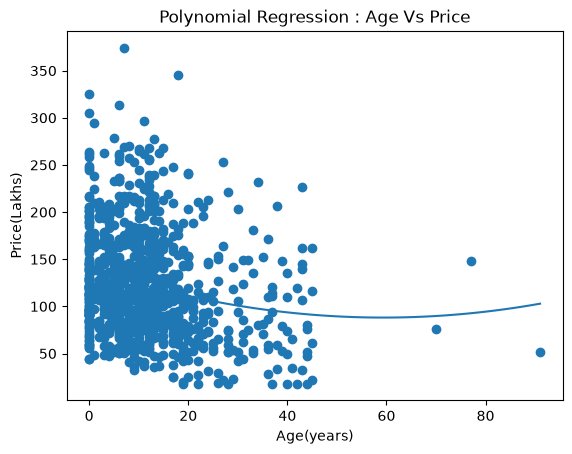

In [82]:
age_range = np.linspace(X_poly['Age_Years'].min(),
                        X_poly['Age_Years'].max(),100).reshape(-1,1)
age_range = pd.DataFrame(age_range, columns=['Age_Years'])
age_range_poly = poly.transform(age_range)
price_pred = poly_model.predict(age_range_poly)
plt.scatter(X_poly['Age_Years'],y_poly)
plt.plot(age_range,price_pred)
plt.title("Polynomial Regression : Age Vs Price")
plt.xlabel("Age(years)")
plt.ylabel("Price(Lakhs)")
plt.show()

### Comparison of train and test values

In [83]:
comparison = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison.head(10)

,Actual,Predicted
943,84.77,95.533716
176,54.25,83.606527
952,78.59,94.531207
847,147.01,184.896565
974,159.89,169.271314
879,99.42,97.480145
704,32.44,56.083790
817,99.96,82.664198
191,110.44,117.598298
11,138.81,133.395705


## Visualize Actual Vs Predicted Value

Text(0, 0.5, 'Predicted Values')

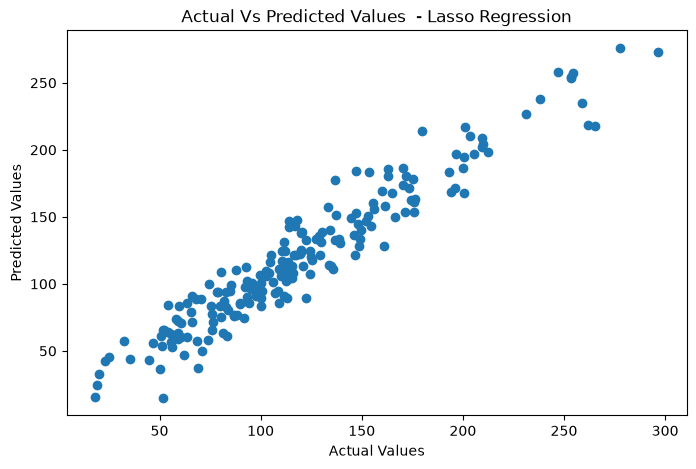

In [84]:
plt.figure(figsize = (8,5))
plt.scatter(y_test,y_pred_lasso)
plt.title("Actual Vs Predicted Values  - Lasso Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# lnferences and Conclusion

**Data Quality & Cleaning**
- The raw dataset (1000 rows, 26 columns) had missing values in `Built_Up_Area_sqft` (2.5%), `Carpet_Area_sqft` (5.4%), `Age_Years` (4.1%), and `Furnishing_Status` (3.4%) — all handled via median/mode imputation.
- 10 duplicate rows were found and dropped, leaving 990 clean records.
- `City` had messy inconsistent casing/spacing (e.g., "PUNE", "pune", " Pune") which was standardized to 5 clean city names.
- `Floor` was a mixed text/numeric field ("Ground", "3rd", "6") and was parsed into a clean numeric `Floor_num`.

**Feature Engineering & Multicollinearity**
- Date-derived features (`Listing_Year`, `Listing_Month`, `Listing_Quarter`, `Days_Since_Listings`) showed extremely high VIF (up to 416), confirming they were redundant re-expressions of `Listing_Date`. All but `Days_Since_Listings` were dropped to remove collinearity.
- Remaining features had healthy VIF values (mostly under 6), indicating no serious multicollinearity issue among the core predictors.

**Key Correlations with Price**
- `Carpet_Area_sqft` (0.86), `BHK` (0.84), and `Bathrooms` (0.76) were the strongest positive correlates of `Price_Lakhs`. `Built_Up_Area_sqft` was more modestly correlated (0.50).

**Model Performance (R² on test set)**

| Model | R² | RMSE (Lakhs) |
|---|---|---|
| Baseline (mean predictor) | -0.003 | 55.17 |
| Simple Linear Regression (area only) | 0.365 | 43.90 |
| Multiple Linear Regression (all features) | 0.918 | 15.78 |
| MLR + SelectKBest (10 features) | 0.884 | 18.74 |
| MLR + PCA (5 components) | 0.856 | 20.90 |
| Ridge (α=1.0) | 0.918 | 15.73 |
| **Ridge (tuned, α≈13.9)** | **0.921** | — |
| **Lasso (tuned, α=0.13)** | **0.921** | 15.53 |
| Ridge + PCA | 0.856 | 20.90 |
| Polynomial (Age only, degree 2) | 0.054 | 53.59 |

**Key Takeaways**
- A single feature (area or age) is a poor predictor alone — full multivariate models are essential, jumping R² from ~0.36–0.05 to over 0.90.
- **Multiple Linear Regression already captures ~92% of price variance**, showing the relationship between property features and price is largely linear.
- Dimensionality reduction (KBest, PCA) actually **hurt** performance slightly — the full feature set carries meaningful, non-redundant signal, so compressing it loses information rather than removing noise.
- Regularization (Ridge/Lasso) gave marginal but real improvement over plain MLR once tuned, with **Lasso at α=0.13 as the best-performing model overall** (R² ≈ 0.921, lowest RMSE/MAE), while also implicitly performing feature selection by shrinking weak coefficients to zero.
- Polynomial regression on `Age_Years` alone confirmed age has a weak, non-linear relationship with price when considered in isolation — not a strong standalone predictor.
- Overall, **property size (carpet area), configuration (BHK), and bathroom count are the dominant price drivers**, and a regularized multiple regression model is the recommended final choice for this dataset.

# Model Deployment

In [89]:
import joblib
joblib.dump(lasso_model,"housing_price_prediction.pkl")

['housing_price_prediction.pkl']

In [90]:
model = joblib.load("housing_price_prediction.pkl")
new_house = pd.DataFrame({'City':['Hyderabad'],
                          'Locality':['Gachibowli'],
                          'Property_Type':['Apartment'],
                          'BHK':[4],
                          'Built_Up_Area_sqft':[1800],
                          'Carpet_Area_sqft':[1200],
                          'Age_Years':[2],
                          'Floor':[10],
                          'Total_Floors':[14],
                          'Bathrooms':[4],
                          'Parking_Spaces':[1],
                          'Furnishing_Status':['Furnished'],
                          'Facing':['East'],
                          'Gated_Community':['Yes'],
                          'Distance_to_Metro_km':[11],
                          'Distance_to_CBD_km':[17],
                          'Nearby_Schools':[6],
                          'Crime_Index':[5.4],
                          'Amenities_Score':[7],
                          'Monthly_Maintenance_INR':[8000],
                          'Seller_Type':['Owner'],
                          'Loan_Available':['Yes'],
                          'Annual_Property_Tax_INR':[30000],
                          'Floor_num':[10],
                          'Days_Since_Listings':400})
print("Cost of the new house is predicted to be Rupess(in lakhs):",model.predict(new_house))

Cost of the new house is predicted to be Rupess(in lakhs): [141.05142536]
